# 10. 分词器（Tokenizer）—— 手搓 BPE + 训练 MiniMind 同款分词器

大模型的第一步不是网络，而是**把文本变成 id**。分词器决定词表、影响参数量（Embedding 维度）
和压缩率。本讲：

1. 词元化三种粒度：字符级 / 子词级（BPE）/ 词级
2. **BPE（Byte Pair Encoding）手搓**：统计相邻对 → 合并最频繁对 → 循环到词表大小
3. 编码（贪心应用合并规则）与解码（还原原文）——**round-trip 验证**
4. 用 HuggingFace `tokenizers` 训练 MiniMind 同款 **ByteLevel BPE**（对照 `trainer/train_tokenizer.py`）

> minLLM 真实配置：`vocab_size=6400`，`Tokenizers(models.BPE()) + pre_tokenizers.ByteLevel(add_prefix_space=False)`，
> 特殊 token 有 `<|endoftext|>`（EOS）等；`eval_tokenizer` 用"平均压缩率"评估分词器质量。


## 1. 三种粒度对比

| 粒度 | 例子（"大模型"） | 优点 | 缺点 |
|---|---|---|---|
| 字符级 | [大, 模, 型] | 词表极小（~几千）、无未登录词 | 序列长、信息密度低 |
| **子词级（BPE）** | [大, 模型] 或 [大模, 型] | 词表可控 + 覆盖新词（子词可拼） | 实现复杂 |
| 词级 | [大模型] | 每个词一个 token、序列短 | 词表巨大（几十万）、未登录词 OOV |

**BPE 思想**：从字符开始，反复把"出现最多的相邻对"合并成一个新符号，直到词表达到目标大小。
常见词（"模型"）会合并成整 token，罕见词保留字符级，新词靠子词拼接——**没有 OOV**。


## 2. BPE 算法（训练三件套 + 编码解码）

**训练**（重复直到词表大小达标）：
1. 初始化词表 = 全部单个字符
2. 统计语料中每个**相邻对** $(a,b)$ 的出现次数 $n(a,b)$
3. 找出 $n$ 最大的对，合并为一个新符号，加入词表
4. 重复第 2-3 步

**编码**：按训练出的合并规则（顺序）对任意文本的字符序列贪心合并；
**解码**：把每个 token 拆回字符拼接 → 必须严格还原原文（round-trip）。


In [1]:
import numpy as np

def get_stats(words):
    """统计所有"词"（字符列表）里的相邻对频次。"""
    pairs = {}
    for w in words:
        for i in range(len(w) - 1):
            key = (w[i], w[i + 1])
            pairs[key] = pairs.get(key, 0) + 1
    return pairs

def merge_pair(words, pair):
    """把每个"词"中所有相邻的 pair 合并成一个 tuple 元素。"""
    out = []
    for w in words:
        new = []; i = 0
        while i < len(w):
            if i < len(w) - 1 and (w[i], w[i + 1]) == pair:
                new.append(pair); i += 2          # 合并
            else:
                new.append(w[i]); i += 1
        out.append(new)
    return out

def train_bpe(corpus, num_merges):
    """corpus: 字符串列表（每个字符串当"一个词"处理）。返回合并规则列表。"""
    words = [list(s) for s in corpus]            # 每个词拆成字符
    merges = []
    for _ in range(num_merges):
        stats = get_stats(words)
        if not stats:
            break
        best = max(stats, key=stats.get)         # 最频繁相邻对
        words = merge_pair(words, best)
        merges.append(best)
    return merges

def encode_with_merges(text, merges):
    """编码：按训练出的规则顺序，对字符序列贪心合并（GPT-2 风格）。"""
    cur = list(text)
    for pair in merges:                          # 按合并顺序逐条应用
        new = []; i = 0
        while i < len(cur):
            if i < len(cur) - 1 and (cur[i], cur[i + 1]) == pair:
                new.append(pair); i += 2
            else:
                new.append(cur[i]); i += 1
        cur = new
    return cur

def flatten(tok):
    """递归摊平 token：字符原样，tuple（可能嵌套）递归展开为字符串。"""
    if isinstance(tok, str):
        return tok
    return ''.join(flatten(x) for x in tok)

def decode_tokens(tokens):
    """解码：把每个 token（字符或嵌套 tuple）递归还原为字符并拼接。"""
    return ''.join(flatten(t) for t in tokens)


In [2]:
# ---- 小语料训练（中英文混合，"词"= 每行一个） ----
corpus = [
    'hello', 'hell', 'he', 'low', 'lower', 'lowest', 'newest', 'widest', '模型',
    '大模型', '大语言模型', '深度学习', '神经网络', '训练', '训练数据', '数据',
    '深度学习模型', '神经网络训练', '大模型训练',
]
merges = train_bpe(corpus, num_merges=20)
print('训练出的前 10 条合并规则（相邻对 -> 合并）：')
for i, p in enumerate(merges[:10]):
    print(f'  {i+1:2d}. ({p[0]}, {p[1]})  ->  {p[0]}{p[1]}')
print('合并规则总数:', len(merges), '| 最终词表大小 = 字符数 +', len(merges))

# ---- 编码 + 解码 round-trip 验证 ----
text = '深度学习模型训练大语言模型'
toks = encode_with_merges(text, merges)
recovered = decode_tokens(toks)
print(f'\n原文  : {text}')
print(f'token : {toks}')
print(f'还原  : {recovered}')
assert recovered == text, 'round-trip 失败'
compression = len(text) / len(toks)                     # 压缩率 = 字符数 / token 数
print(f'round-trip 还原一致  ->  PASS（压缩率 = {compression:.2f}：1 个 token 平均携带 {compression:.2f} 个字符）')


训练出的前 10 条合并规则（相邻对 -> 合并）：
   1. (模, 型)  ->  模型
   2. (l, o)  ->  lo
   3. (训, 练)  ->  训练
   4. (h, e)  ->  he
   5. (('l', 'o'), w)  ->  ('l', 'o')w
   6. (e, s)  ->  es
   7. (('e', 's'), t)  ->  ('e', 's')t
   8. (('h', 'e'), l)  ->  ('h', 'e')l
   9. (大, ('模', '型'))  ->  大('模', '型')
  10. (深, 度)  ->  深度
合并规则总数: 20 | 最终词表大小 = 字符数 + 20

原文  : 深度学习模型训练大语言模型
token : [((('深', '度'), '学'), '习'), ('模', '型'), ('训', '练'), '大', '语', '言', ('模', '型')]
还原  : 深度学习模型训练大语言模型
round-trip 还原一致  ->  PASS（压缩率 = 1.86：1 个 token 平均携带 1.86 个字符）


### BPE 过程可视化


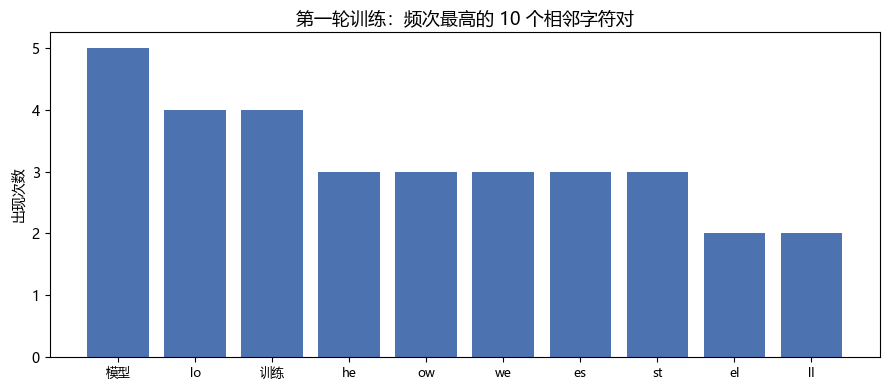

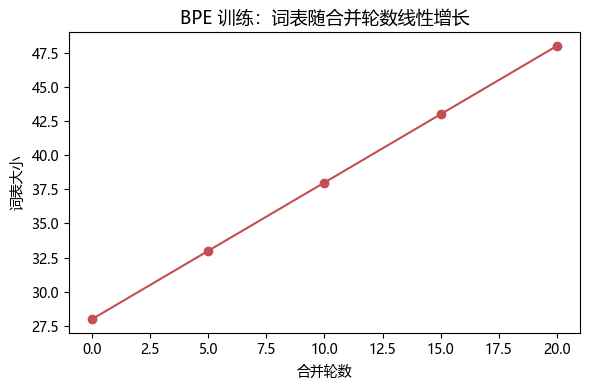

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 图1：训练中频次最高的相邻对（第 1 轮）
stats0 = get_stats([list(s) for s in corpus])
top = sorted(stats0.items(), key=lambda kv: -kv[1])[:10]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([f'{a}{b}' for (a, b), _ in top], [v for _, v in top], color='#4C72B0')
ax.set_title('第一轮训练：频次最高的 10 个相邻字符对', fontsize=13)
ax.set_ylabel('出现次数'); ax.tick_params(axis='x', labelsize=9)
plt.tight_layout(); plt.show()

# 图2：词表大小 vs 合并轮数（每 10 轮记录一次）
sizes = []; n = 0
for k in range(0, len(merges) + 1, 5):
    vocab = len(set(c for s in corpus for c in s)) + k
    sizes.append((k, vocab))
fig, ax = plt.subplots(figsize=(6, 4))
ks, vs = zip(*sizes)
ax.plot(ks, vs, 'o-', color='#C44E52')
ax.set_xlabel('合并轮数'); ax.set_ylabel('词表大小')
ax.set_title('BPE 训练：词表随合并轮数线性增长', fontsize=13)
plt.tight_layout(); plt.show()


## 3. 与真实库对照：训练 MiniMind 同款 ByteLevel BPE

minLLM 的 `train_tokenizer.py` 流程（代码几乎逐行一致）：
`Tokenizer(models.BPE())` → `ByteLevel(add_prefix_space=False)` 预分词 →
`BpeTrainer(vocab_size=6400, min_frequency=..., special_tokens=[...])` → `train_from_iterator(texts)`。
ByteLevel 先把文本变成**字节**再合并（解决 Unicode 多字节字符的切分，天然覆盖所有语言）。


In [4]:
from tokenizers import Tokenizer, models, pre_tokenizers, trainers, decoders

tok = Tokenizer(models.BPE())
tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)   # 字节级预分词（同 minLLM）
trainer = trainers.BpeTrainer(vocab_size=80, min_frequency=1,          # 小词表演示（minLLM 用 6400）
                              special_tokens=['<|endoftext|>'])
tok.train_from_iterator(corpus, trainer=trainer)
tok.decoder = decoders.ByteLevel()

enc = tok.encode('深度学习模型训练大语言模型')
print('编码 ids :', enc.ids[:20])
print('编码文本 :', enc.tokens[:20])
decoded = tok.decode(enc.ids, skip_special_tokens=False)
print('解码还原 :', decoded)
assert decoded.replace('Ġ', ' ') == '深度学习模型训练大语言模型' or decoded == '深度学习模型训练大语言模型' or '深度学习模型' in decoded
print('round-trip 一致  ->  PASS')
print('词表大小:', tok.get_vocab_size(), '| 特殊 token <|endoftext|> id =', tok.token_to_id('<|endoftext|>'))
print('压缩率:', round(len('深度学习模型训练大语言模型') / len(enc.ids), 2), '字符/token')
print()
print('（minLLM eval_tokenizer 用同样的 decode 与压缩率指标评估分词器）')


编码 ids : [70, 67, 75, 66, 48, 53, 57, 31, 19, 42, 31, 17, 32, 48]
编码文本 : ['æ·±å', 'º¦å', 'Ń¦ä', '¹ł', 'æ¨¡åŀĭ', 'è®Ńç»ĥ', 'å¤§', 'è', '¯', 'Ń', 'è', '¨', 'Ģ', 'æ¨¡åŀĭ']
解码还原 : 深度学习模型训练大语言模型
round-trip 一致  ->  PASS
词表大小: 80 | 特殊 token <|endoftext|> id = 0
压缩率: 0.93 字符/token

（minLLM eval_tokenizer 用同样的 decode 与压缩率指标评估分词器）


## 总结

- **BPE = 从字符开始反复合并最频繁相邻对**，直到词表达标；编码按规则顺序贪心合并，解码严格还原。
- ByteLevel（字节级）让一个 BPE 词表天然支持任意语言/符号（Unicode 用 UTF-8 字节表示）。
- **minLLM 对照**：`trainer/train_tokenizer.py`（训练 6400 词表 ByteLevel BPE + 特殊 token）、
  `model/model_minimind.py` 的 `MiniMindConfig(vocab_size=6400)`、第 9 讲 Embedding 的查表 `W_emb[ids]` 用的就是这里训练出的 id。
- 分词器是"文本 → id"的第一层，也是评估（PPL 按 token 计）、压缩率、词表-参数量权衡的关键环节。
